# LLM setup

In [2]:
!pip install ollama -q > /dev/null

In [22]:
# Importing all the necessary libraries
import pandas as pd
import zipfile
import os
import json
import ollama
import re
from collections import Counter
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Path to the ZIP file
zip_file_path = '/content/drive/My Drive/Files/file.zip'

# Temporary folder to extract JSON files
extract_folder = '/content/json_files'

# Extract all files from the ZIP
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

# Initialize a list to store data
dataframes = []

# Iterate over each JSON file in the extracted folder
for file_name in os.listdir(extract_folder):
    if file_name.endswith('.json'):  # Check if it's a JSON file
        file_path = os.path.join(extract_folder, file_name)
        try:
            # Read the JSON file
            with open(file_path, 'r', encoding='utf-8') as file:
                data = json.load(file)

                df_temp = pd.DataFrame(data)
                dataframes.append(df_temp)
        except Exception as e:
            print(f"Error reading {file_name}: {e}")

# Combine all DataFrames into one named df
df = pd.concat(dataframes, ignore_index=True)

In [46]:
df.columns

Index(['Title', 'URL', 'Area', 'Published', 'Description', 'Job Link',
       'HTML_Text', 'word_count', 'Extracted_Skills', 'Primary_Skills'],
      dtype='object')

In [7]:
df['HTML_Text'].iloc[150]

'Lignende jobannoncer Job i Region Midtjylland kategoriseret i Database (39) Jobindex Jobannoncearkiv Dette er en gammel version af jobannoncen, som blev gemt 2016-02-15 02:38:34. Bemærk, at jobannoncen ikke længere er aktuel og firmaet derfor sandsynligvis ikke længere ønsker at modtage ansøgninger. This is an old version of the job ad, which was saved on 2016-02-15 02:38:34. Please note that this job ad has expired and that the company is probably no longer interested in receiving applications.'

## maybe we should remove the ones where the area is unknown

In [49]:
unknown_area_count = df['Area'].value_counts().get('Unknown', 0)
print(f"Number of 'unknown' Areas: {unknown_area_count}")

Number of 'unknown' Areas: 476


In [50]:
# Get all unique values in the 'Area' column
unique_areas = df['Area'].unique()

# Print the unique values
print(f"Unique Areas: {unique_areas}")

Unique Areas: ['København' 'Ballerup' 'Region Nordjylland' 'Unknown' 'Grønland' 'Nuuk'
 'Aarhus' 'Roskilde' 'Humlebæk' 'Hørsholm' 'Rødovre' 'Billund' 'Hellerup'
 'Brøndby' 'Horsens' 'Silkeborg' 'Copenhagen'
 'København, Aarhus eller Odense/København' 'Lystrup' 'Viby J'
 'Region Midtjylland' 'Udlandet' 'København K' 'Odense M' 'København V'
 'Ukraine' 'København Ø' 'Frederiksberg' 'Kvistgaard' 'Høje Taastrup'
 'Søborg' 'Smørum' 'Allerød' 'Hillerød' 'Århus' 'Storkøbenhavn'
 'København S' 'Odense SØ' 'Højbjerg' 'Bagsværd' 'København N' 'Polen'
 'Gentofte' 'Sønderborg' 'Stilling' 'Taastrup eller Aarhus'
 'København eller Århus' 'Vingsted' 'Region Sjælland' 'Valby' 'Ebeltoft'
 'Hvidovre' 'Hinnerup' 'Aalborg' 'Nykøbing F'
 'Danmark, Storkøbenhavn, Valby' 'Lejre' 'Ikast' 'Odense eller Ballerup'
 'Esbjerg' 'Gråsten' 'Albertslund' 'Aarhus V' 'Glostrup' 'Herlev'
 'Belgien' 'Kalundborg' 'Kastrup' 'Helsingør' 'Brande and Aarhus' 'Lyngby'
 'Skive' 'Taastrup' 'Birkerød' 'Fredericia' 'Herning' 'Kgs. 

In [8]:
# Calculate word counts for each row in the 'HTML_Text' column
df['word_count'] = df['HTML_Text'].apply(lambda x: len(x.split()))

# Generate statistics on the word counts
stats = df['word_count'].describe()

# Print the statistics
print(stats)

count    3229.000000
mean      650.489935
std       331.091993
min        66.000000
25%       471.000000
50%       690.000000
75%       841.000000
max      4080.000000
Name: word_count, dtype: float64


## the ads with a word count bellow this number don't seem to give us much to work with

In [11]:
# Define a threshold for minimum word count
min_word_count = 400

# Filter the original dataframe in place, only keeping rows meeting the word count requirement
df = df[df['HTML_Text'].apply(lambda x: len(x.split()) > min_word_count)].copy()

df.shape

(2537, 8)

In [12]:
# Install Ollama
!sudo apt-get install -y pciutils
!curl -fsSL https://ollama.com/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpci3 pci.ids
The following NEW packages will be installed:
  libpci3 pci.ids pciutils
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 343 kB of archives.
After this operation, 1,581 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 pci.ids all 0.0~2022.01.22-1 [251 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpci3 amd64 1:3.7.0-6 [28.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 pciutils amd64 1:3.7.0-6 [63.6 kB]
Fetched 343 kB in 2s (177 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 3.)
debconf: falling back to frontend: Readline
debconf: unable to initializ

In [14]:
# Sets up environment variables and starts the Ollama server
import os
import threading
import subprocess

def start_ollama():
    os.environ['OLLAMA_HOST'] = '0.0.0.0:11434'
    os.environ['OLLAMA_ORIGINS'] = '*'
    subprocess.Popen(["ollama", "serve"])

ollama_thread = threading.Thread(target=start_ollama)
ollama_thread.start()

In [15]:
!ollama run llama3.1:8b

pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠹ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠇ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠦ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠼ pulling manifest ⠦ pulling manifest ⠦ pulling manifest ⠧ pulling manifest 
pulling 667b0c1932bc...   0% ▕▏    0 B/4.9 GB                  pulling manifest 
pulling 667b0c1932bc...   0% ▕▏    0 B/4.9 GB                  pulling manifest 
pulling 667b0c1932bc...   0% ▕▏    0 B/4.9 GB                  pulling manifest 
pulling 667b0c1932bc...   0% ▕▏    0 B/4.9 GB                  pulling manifest 
pulling 667b0c1932bc...   0% ▕▏    0 B/4.9 GB                  pulling manifest 
pulling 667b0c1932bc...   0% ▕▏    0 B/4.9 GB

In [16]:
SYSTEM_PROMPT = """
Extract relevant IT skills from a job listing text, focusing exclusively on actionable and specific primary/core IT-related technical skills.

### Primary Skills to Extract
Focus on specific technical skills, tools, platforms, programming languages, and related technologies in the IT domain. These include:

1. Programming and Development
   - Languages: Python, Java, C++, JavaScript, C#.
   - Frameworks: React, Angular, Django, Spring.
   - UX/UI Tools: Figma, Sketch, Adobe XD, Axure RP, InVision.

2. Infrastructure and Cloud
   - Networking: TCP/IP, DNS, VPN, routing/switching.
   - Cloud Platforms: AWS, Azure, Google Cloud.
   - Containerization and Virtualization: Docker, Kubernetes, VMware.

3. System Administration and Cybersecurity
   - Operating Systems: Windows, Linux, macOS.
   - Cybersecurity: Firewalls, encryption, penetration testing.
   - Monitoring Tools: Nagios, Zabbix, Splunk.

4. Data and Emerging Technologies
   - Databases: SQL, NoSQL, MongoDB.
   - AI/ML Frameworks: TensorFlow, PyTorch.
   - Other Technologies: Blockchain, IoT tools.

### Rules for Extraction:

- Extract only primary/core IT technical skills explicitly mentioned in the text.
- Ignore soft skills, general traits, or responsibilities.
- Split compound terms into distinct skills (e.g., "Python and Java" → ["Python", "Java"]).
- Ensure all terms are clear, actionable, and concise.

Output Format:

Provide the extracted skills in the following structured JSON format:
{
  "skills": {
    "primary": ["Skill 1", "Skill 2", "..."]
  }
}

Examples:

#### Example 1
Job Listing: "We need a developer skilled in Python, React, and cloud services like AWS."
Output:
{
  "skills": {
    "primary": ["Python", "React", "AWS"]
  }
}

#### Example 2
Job Listing: "Looking for someone with Java programming experience and expertise in databases like SQL."
Output:
{
  "skills": {
    "primary": ["Java", "SQL"]
  }
}

#### Example 3
Job Listing: "The candidate should have experience with Docker, Kubernetes, and Azure."
Output:
{
  "skills": {
    "primary": ["Docker", "Kubernetes", "Azure"]
  }
}

#### Example 4
Job Listing: "Expertise in Linux, Python, and penetration testing is required."
Output:
{
  "skills": {
    "primary": ["Linux", "Python", "Penetration Testing"]
  }
}
"""

In [17]:
# Sets up environment variables and starts the Ollama server
import os
import threading
import subprocess

def start_ollama():
    os.environ['OLLAMA_HOST'] = '0.0.0.0:11434'
    os.environ['OLLAMA_ORIGINS'] = '*'
    subprocess.Popen(["ollama", "serve"])

ollama_thread = threading.Thread(target=start_ollama)
ollama_thread.start()

In [18]:
import pandas as pd
import json

# Function to extract primary/core IT skills from job listings
def extract_primary_skills(html_text, row_id):
    prompt = f"""
    Extract relevant IT skills mentioned in the following job listing text. Focus only on actionable and specific primary/core IT-related technical skills.

    Primary Skills:
    - Core IT-related technical skills (e.g., programming languages, frameworks, tools, methodologies, platforms, or specific technologies).

    ### Rules:
    - Split compound skills connected by conjunctions like "and," "or," or "&" into separate distinct skills (e.g., "Python and Java" → ["Python", "Java"]).
    - Ensure the output is in clear and concise English.

    Provide the results in this JSON format:
    {{
      "skills": {{
        "primary": ["Skill 1", "Skill 2", "..."]
      }}
    }}

    Job listing text:
    {html_text}
    """
    try:
        response = ollama.chat(
            model='llama3.1:8b',
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user', 'content': prompt},
            ],
            format='json',
            options={"temperature": 0.1}  # Low randomness for consistency
        )
        return json.loads(response['message']['content'])
    except (json.JSONDecodeError, KeyError) as e:
        print(f"Error parsing JSON for Row {row_id}: {e}")
        return {
            "skills": {
                "primary": []
            }
        }

# Function to refine extracted primary skills
def refine_primary_skills(extracted_skills, row_id):
    refinement_prompt = f"""

    The following skills were extracted from a job listing. If the input is empty, return an empty result. Review and refine the extracted skills to ensure accuracy, consistency, and alignment with IT-related requirements.

    Extracted Information:
    {json.dumps(extracted_skills, indent=2)}

    Refine the skills into:
    - Primary Skills: Core IT-related technical skills (e.g., programming languages, frameworks, tools, methodologies, platforms).
    - Examples: Python, Java, AWS, Docker, SQL, Agile, Scrum, Kubernetes, etc.

    ### Rules:

    - Split compound skills connected by conjunctions into distinct skills (e.g., "Python and Java" → ["Python", "Java"]).
    - Exclude vague, irrelevant, or non-actionable skills.
    - Ensure all skills are actionable, specific, and IT-relevant.
    - If no skills are present in the input, output an empty "primary" list.
    - Ensure the output is in clear and concise English.
    - Retain IT-relevant skills, even if they overlap with methodologies or specialized tools (e.g., Agile, Photoshop, ITIL).

    Example:
    Refined Skills: 'Python and Docker' → ['Python', 'Docker']

    Provide the results in this JSON format:
    {{
      "skills": {{
        "primary": ["Skill 1", "Skill 2", "..."]
      }}
    }}
    """

    try:
        response = ollama.chat(
            model='llama3.1:8b',
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user', 'content': refinement_prompt},
            ],
            format='json',
            options={"temperature": 0.1}  # Low randomness for consistency
        )
        return json.loads(response['message']['content'])
    except (json.JSONDecodeError, KeyError) as e:
        print(f"Error refining skills for Row {row_id}: {e}")
        return extracted_skills  # Return original skills if refinement fails

# Process job listings
skills_list = []
for i, html_text in enumerate(df['HTML_Text'][:20]):
    # Extract skills
    extracted = extract_primary_skills(html_text, row_id=i + 1)
    print(f"Extracted Primary Skills from Row {i + 1}: {extracted}")

    # Refine extracted skills
    refined = refine_primary_skills(extracted, row_id=i + 1)
    print(f"Refined Primary Skills for Row {i + 1}: {refined}")

    skills_list.append(refined)

# Save the refined skills to a JSON file
output_file = 'refined_primary_skills.json'
try:
    with open(output_file, 'w', encoding='utf-8') as file:
        json.dump({"skills_listings": skills_list}, file, ensure_ascii=False, indent=4)
    print(f"Refined primary skills information saved to {output_file}.")
except IOError as e:
    print(f"Error saving file: {e}")


Extracted Primary Skills from Row 1: {'skills': {'primary': ['Python', 'Java', 'C++', 'JavaScript', 'C#', 'React', 'Angular', 'Django', 'Spring', 'Figma', 'Sketch', 'Adobe XD', 'Axure RP', 'InVision', 'TCP/IP', 'DNS', 'VPN', 'Routing/Switching', 'AWS', 'Azure', 'Google Cloud', 'Docker', 'Kubernetes', 'VMware', 'Linux', 'macOS', 'Windows', 'SQL', 'NoSQL', 'MongoDB', 'TensorFlow', 'PyTorch', 'Blockchain', 'IoT tools']}}
Refined Primary Skills for Row 1: {'skills': {'primary': ['Python', 'Java', 'C++', 'JavaScript', 'C#', 'React', 'Angular', 'Django', 'Spring', 'Figma', 'Sketch', 'Adobe XD', 'Axure RP', 'InVision', 'TCP/IP', 'DNS', 'VPN', 'AWS', 'Azure', 'Google Cloud', 'Docker', 'Kubernetes', 'VMware', 'Linux', 'macOS', 'Windows', 'SQL', 'NoSQL', 'MongoDB', 'TensorFlow', 'PyTorch']}}
Extracted Primary Skills from Row 2: {'skills': {'primary': ['Python', 'Java', 'JavaScript', 'AWS', 'Azure', 'Google Cloud', 'Docker', 'Kubernetes', 'VMware', 'SQL', 'NoSQL', 'MongoDB', 'TensorFlow', 'PyTorc

In [52]:
def format_skill_name(skill):

    # Preserve words written in uppercase (e.g., acronyms like "SQL").
    # Capitalize the first letter of other words (e.g., "python" → "Python").

    return " ".join(
        word if word.isupper() else word.capitalize() for word in skill.split()
    )

def standardize_skill(skill):

    # Remove redundant terms.
    # Map synonyms to standardized terms.
    # Apply case formatting using `format_skill_name`

    # Map synonyms
    synonyms = {
        "node.js": "Node.js",
        "react.js": "React",
        ".net framework": ".NET",
        "macos": "macOS",
        "networking": "TCP/IP"
    }
    standardized_skill = synonyms.get(skill.lower(), skill)

    # Apply formatting using `format_skill_name`
    standardized_skill = format_skill_name(standardized_skill)

    # Remove broad terms or unnecessary words
    broad_terms = {"security", "testing", "development"}
    if standardized_skill.lower() in broad_terms:
        return None  # Skip broad terms

    return standardized_skill

# Apply the formatting and standardization to the skills_list
formatted_skills_list = []

for skill in skills_list:
    primary_skills = skill.get("skills", {}).get("primary", [])
    formatted_primary_skills = [
        standardize_skill(skill) for skill in primary_skills if standardize_skill(skill)
    ]

    # Update the formatted skills list
    skill["skills"]["primary"] = formatted_primary_skills
    formatted_skills_list.append(skill)

# Display the updated skills list
print(formatted_skills_list)

[{'skills': {'primary': ['Python', 'Java', 'C++', 'Javascript', 'C#', 'React', 'Angular', 'Django', 'Spring', 'Figma', 'Sketch', 'Adobe XD', 'Axure RP', 'Invision', 'TCP/IP', 'DNS', 'VPN', 'AWS', 'Azure', 'Google Cloud', 'Docker', 'Kubernetes', 'Vmware', 'Linux', 'Macos', 'Windows', 'SQL', 'Nosql', 'Mongodb', 'Tensorflow', 'Pytorch']}}, {'skills': {'primary': ['Python', 'Java', 'Javascript', 'AWS', 'Azure', 'Google Cloud', 'Docker', 'Kubernetes', 'Vmware', 'SQL', 'Nosql', 'Mongodb', 'Tensorflow', 'Pytorch']}}, {'skills': {'primary': ['Python', 'Java', 'C++', 'Javascript', 'AWS', 'Azure', 'Google Cloud', 'Docker', 'Kubernetes', 'Vmware']}}, {'skills': {'primary': ['Oracle Fusion Middleware', 'Java', 'Python', 'SQL', 'Oracle Technology']}}, {'skills': {'primary': []}}, {'skills': {'primary': ['Java', 'Angularjs', 'Javascript', 'SQL', 'Zkoss', 'REST', 'LESS', 'Apache Tomcat', 'Oracle', 'Subversion', 'Maven']}}, {'skills': {'primary': ['HTML', 'CSS', 'Javascript', 'ES6', 'React', 'Node.js'

Total Unique Skills: 94


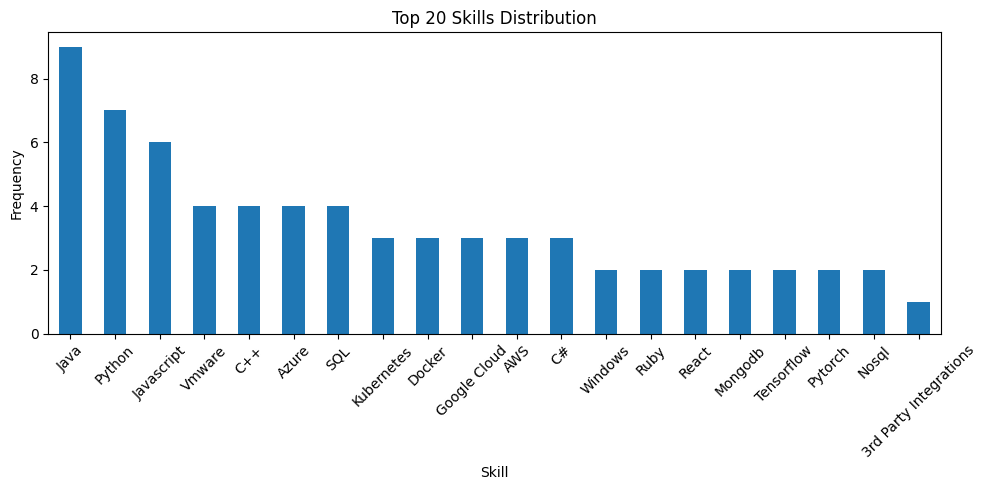

In [27]:
# Flatten and count skills
skill_counts = Counter(skill for entry in formatted_skills_list for skill in entry["skills"]["primary"])

# Create a DataFrame and sort
skill_df = pd.DataFrame(skill_counts.items(), columns=['Skill', 'Count']).sort_values(by='Count', ascending=False)

# Display total unique skills
print(f"Total Unique Skills: {len(skill_df)}")

# Plot top 20 skills
skill_df.head(20).plot(kind='bar', x='Skill', y='Count', figsize=(10, 5), legend=False)
plt.title('Top 20 Skills Distribution')
plt.ylabel('Frequency')
plt.xlabel('Skill')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Creating the df with skills column. Might have to be optimised

In [44]:
processed_indexes = df.index[:20]  # Number of rows sent to the LLM
assert len(formatted_skills_list) == len(processed_indexes), "Mismatch between processed rows and extracted skills!"

# Create a new DataFrame to store skills
df_skills = df.copy()

# Add a new column with default values (None for rows not sent to LLM)
df_skills["Extracted_Skills"] = None

# Assign the formatted skills to the corresponding rows
for idx, skills in zip(processed_indexes, formatted_skills_list):
    df_skills.at[idx, "Extracted_Skills"] = skills

# Create a new column for only the primary skills as a list
df_skills["Primary_Skills"] = df_skills["Extracted_Skills"].apply(
    lambda x: x.get("skills", {}).get("primary", []) if x else []
)

# Save the final DataFrame to a file
df_skills.to_csv("processed_skills.csv", index=False)

# Print a sample of the resulting DataFrame
df_skills.head(20)

,Title,URL,Area,Published,Description,Job Link,HTML_Text,word_count,Extracted_Skills,Primary_Skills
0,Consultants to Information Security and IT Ris...,https://www.jobindex.dk/vis-job/r6572791,København,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Storkøbenhavn kateg...,815,"{'skills': {'primary': ['Python', 'Java', 'C++...","[Python, Java, C++, Javascript, C#, React, Ang..."
1,Digital Commerce Consultant,https://www.jobindex.dk/vis-job/r6572748,København,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Storkøbenhavn kateg...,589,"{'skills': {'primary': ['Python', 'Java', 'Jav...","[Python, Java, Javascript, AWS, Azure, Google ..."
2,Experienced Infrastructure Consultant for IT S...,https://www.jobindex.dk/vis-job/r6572792,København,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Storkøbenhavn kateg...,610,"{'skills': {'primary': ['Python', 'Java', 'C++...","[Python, Java, C++, Javascript, AWS, Azure, Go..."
3,Oracle Fusion Middleware Consultant,https://www.jobindex.dk/vis-job/r6572750,København,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Storkøbenhavn kateg...,526,{'skills': {'primary': ['Oracle Fusion Middlew...,"[Oracle Fusion Middleware, Java, Python, SQL, ..."
4,Head of Accounting,https://www.jobindex.dk/vis-job/r6572778,København,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Storkøbenhavn kateg...,625,{'skills': {'primary': []}},[]
5,Web/Software Developer to R&D,https://www.jobindex.dk/vis-job/r6572830,Ballerup,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Storkøbenhavn kateg...,499,"{'skills': {'primary': ['Java', 'Angularjs', '...","[Java, Angularjs, Javascript, SQL, Zkoss, REST..."
6,Prototype Developer,https://www.jobindex.dk/vis-job/r6572827,København,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Storkøbenhavn kateg...,479,"{'skills': {'primary': ['HTML', 'CSS', 'Javasc...","[HTML, CSS, Javascript, ES6, React, Node.js, P..."
7,Head of IT Audit,https://www.jobindex.dk/vis-job/r6572793,København,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Storkøbenhavn kateg...,667,{'skills': {'primary': []}},[]
8,Erfaren C# Udvikler,https://www.jobindex.dk/vis-job/r6576938,Region Nordjylland,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Region Nordjylland ...,432,"{'skills': {'primary': ['C#', 'Java']}}","[C#, Java]"
9,Android Engineer,https://www.jobindex.dk/vis-job/r6572834,København,2016-01-10,Relevant details not found in the PaidJob-inne...,https://www.jobindexarkiv.dk/cgi/showarchive.c...,Lignende jobannoncer Job i Storkøbenhavn kateg...,423,"{'skills': {'primary': ['Java', 'Android', 'C+...","[Java, Android, C++, JNI, Sqlite, Ormlite]"


In [53]:
df_skills.columns

Index(['Title', 'URL', 'Area', 'Published', 'Description', 'Job Link',
       'HTML_Text', 'word_count', 'Extracted_Skills', 'Primary_Skills'],
      dtype='object')

# API for getting lat and lon for each area

In [107]:
from geopy.geocoders import Nominatim

# Initialize the geocoder
geolocator = Nominatim(user_agent="geoapi")

# Geocode an area
location = geolocator.geocode("Aalborg")
print(location.latitude, location.longitude)

57.0462626 9.9215263


# API for getting population in each area. Allows us to calculate jobs per capita as suggested by Primoz

In [103]:
import pandas as pd
import requests
from io import StringIO

# Define the parameters for the population data request
params = {
    'table': 'FOLK1A',  # Table for population
    'format': 'BULK',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},  # All areas
        {'code': 'Tid', 'values': ['2016K1', '2024K4']},  # From 2016 Q1 to 2024 Q4
        {'code': 'KØN', 'values': ['TOT']},  # Total population (ignore gender)
        {'code': 'ALDER', 'values': ['IALT']},  # Total population (ignore age categories)
        {'code': 'CIVILSTAND', 'values': ['TOT']}  # Total marital status (ignore specific statuses)
    ]
}

# Make the request to the API
response = requests.post('https://api.statbank.dk/v1/data', json=params)
data = response.text

# Check if we received a valid response
if 'errorTypeCode' in data:
    print("Error:", data)
else:
    # Load the response into a pandas DataFrame using StringIO
    population = pd.read_csv(StringIO(data), sep=';')

    # Display the column names to check their actual names
    print(population.columns)

    # Clean column names by stripping spaces
    population.columns = population.columns.str.strip()

    # Filter the columns to focus on 'OMRÅDE', 'TID', and 'INDHOLD'
    population = population[['OMRÅDE', 'TID', 'INDHOLD']]

    # Convert 'INDHOLD' to numeric in case there are any non-numeric entries
    population['INDHOLD'] = pd.to_numeric(population['INDHOLD'], errors='coerce')

    # Group the data by area and time, summing up the population values
    population_grouped = population.groupby(['OMRÅDE', 'TID']).sum().reset_index()

    # Sort by time for better visualization
    population_grouped = population_grouped.sort_values(by='TID')

    # Display the resulting DataFrame
    print(population_grouped.head())

Index(['OMRÅDE', 'TID', 'KØN', 'ALDER', 'CIVILSTAND', 'INDHOLD'], dtype='object')
       OMRÅDE     TID  INDHOLD
0    Aabenraa  2016K1    58869
134     Odder  2016K1    22131
132   Næstved  2016K1    82342
130    Nyborg  2016K1    31886
128  Nordfyns  2016K1    29298
